# **Dataset Overview**

### 📦 **Sumber Dataset:**

Dataset: [Fashion Products – Kaggle](https://www.kaggle.com/datasets/bhanupratapbiswas/fashion-products)

---

### 📝 **Deskripsi Dataset:**

Dataset ini berisi informasi umum tentang berbagai produk fashion yang dijual secara online, mencakup detail produk, merek, kategori, harga, rating pengguna, serta variasi warna dan ukuran. Dataset ini cocok digunakan untuk analisis tren produk fashion, membangun sistem rekomendasi, segmentasi pelanggan, dan berbagai aplikasi lain di bidang e-commerce dan retail fashion.

---

### 🔧 **Fitur (Atribut) dalam Dataset:**

* User ID
* Product ID
* Product Name
* Brand
* Category
* Price
* Rating
* Color
* Size

---

### 🔗 **Akses Dataset:**

👉 [Fashion Products Dataset di Kaggle](https://www.kaggle.com/datasets/bhanupratapbiswas/fashion-products)

# **Import Library**

Pada tahap ini, kita akan mengimpor berbagai library Python yang diperlukan untuk proses eksplorasi data, analisis, dan visualisasi.

**Menginstall library surprise**

In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2463325 sha256=3a132923e54a0b61fb416d907c929433d12f52ef26ca2949f471b627928629e5
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


### 📝 **Penjelasan:**

* **`!pip install`** → perintah untuk menginstal library Python langsung dari dalam notebook (misalnya Jupyter Notebook atau Google Colab). Tanda seru (`!`) artinya kita menjalankan perintah **shell/terminal** dari dalam notebook.
* **`surprise`** → nama library yang diinstal.
  Surprise (Simple Python RecommendatIon System Engine) adalah library Python yang dirancang khusus untuk membangun dan menganalisis **sistem rekomendasi**, terutama berbasis **collaborative filtering**.

**Uninstall library numpy**

In [ ]:
!pip uninstall -y numpy


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


### 📝 **Penjelasan:**

* **`!pip uninstall`** → perintah untuk menghapus (uninstall) sebuah library Python dari environment yang sedang digunakan.
* **`-y`** → artinya **langsung jawab “yes”** tanpa perlu konfirmasi manual saat proses uninstall berlangsung.
* **`numpy`** → nama library yang akan dihapus.

---

### 💡 **Kenapa perlu dijalankan?**

Karena:
✅ **Surprise** hanya kompatibel dengan **numpy versi < 2.0**, sedangkan kalau kamu pakai environment atau Google Colab terbaru, biasanya `numpy` yang terinstall sudah otomatis **versi 2.x**.
✅ Kalau langsung pakai Surprise tanpa downgrade numpy, biasanya muncul error

**Install library numpy**

In [ ]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 44.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


### 📝 **Penjelasan:**

* Perintah ini menginstruksikan sistem untuk menginstal **library numpy** dengan **versi kurang dari 2.0**.
* Tanda kutip `"numpy<2"` memastikan bahwa versi numpy yang terinstall adalah versi 1.x (atau apapun yang lebih rendah dari 2).
* Ini penting karena beberapa library, seperti **Surprise**, belum kompatibel dengan numpy versi 2.x yang terbaru.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
from surprise import accuracy


# **Data Understanding**

**Data Understanding** adalah langkah awal dalam proyek machine learning atau data science yang bertujuan untuk memahami isi, struktur, dan kualitas data yang akan digunakan. Pada tahap ini, kita memeriksa kelengkapan data, tipe data, distribusi dasar, serta potensi masalah seperti missing values dan duplikasi agar proses analisis dan pemodelan berjalan efektif dan akurat.


## **Load Dataset**

Pada tahap ini, kita membaca file data utama `fashion_products.csv` yang sudah berhasil diunduh dan diekstrak dari Kaggle. File ini berisi data produk fashion yang mencakup informasi produk, merek, kategori, harga, rating, warna, dan ukuran, yang akan digunakan untuk analisis dan pengembangan model selanjutnya. Data dimuat ke dalam struktur DataFrame menggunakan library pandas agar proses eksplorasi dan manipulasi data menjadi lebih mudah dan efisien.

In [ ]:
from google.colab import files
from IPython.display import clear_output

uploaded = files.upload()
clear_output()  # Menghilangkan output upload agar tidak tampil

# Kalau mau, kita bisa cek nama file yang diupload tanpa print langsung
print(f"File berhasil diupload: {list(uploaded.keys())[0]}")


File berhasil diupload: kaggle.json


In [ ]:
# Buat folder untuk credential Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset Fashion Products dari Kaggle
!kaggle datasets download -d bhanupratapbiswas/fashion-products

# Ekstrak file zip hasil download
!unzip fashion-products.zip


Dataset URL: https://www.kaggle.com/datasets/bhanupratapbiswas/fashion-products
License(s): other
  0% 0.00/19.7k [00:00<?, ?B/s]
100% 19.7k/19.7k [00:00<00:00, 46.2MB/s]
Archive:  fashion-products.zip
  inflating: fashion_products.csv    


## **Struktur & Sampel Data**

Tahap ini bertujuan untuk memahami berapa banyak data yang tersedia dan melihat contoh isi tiap kolom.

In [ ]:
# Membaca file
df = pd.read_csv('fashion_products.csv')

# Ukuran data dan sampel awal
print(f"Jumlah baris dan kolom: {df.shape}")
df.head()

Jumlah baris dan kolom: (1000, 9)


,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M


### 🔍 **Insight Dataset Fashion Products**

* Dataset berisi **1000 baris** dan **9 kolom** yang merepresentasikan produk fashion dan informasi terkait.

* Contoh data menunjukkan variasi produk seperti Dress, Shoes, T-shirt dari berbagai brand populer seperti Adidas, H\&M, dan Zara.

* Produk mencakup kategori fashion pria dan wanita (Men’s Fashion, Women’s Fashion).

* Harga produk bervariasi, misalnya dari 23 sampai 82 (dalam satuan yang tidak disebutkan, kemungkinan dolar atau rupiah).

* Rating produk memiliki nilai desimal, dengan contoh mulai dari sekitar 1 sampai lebih dari 4, menunjukkan variasi kualitas atau kepuasan pengguna terhadap produk.

* Warna dan ukuran produk juga bervariasi, yang memungkinkan analisis preferensi konsumen berdasarkan atribut visual dan ukuran.

## **Info Kolom dan Tipe Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User ID       1000 non-null   int64  
 1   Product ID    1000 non-null   int64  
 2   Product Name  1000 non-null   object 
 3   Brand         1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Price         1000 non-null   int64  
 6   Rating        1000 non-null   float64
 7   Color         1000 non-null   object 
 8   Size          1000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


### 🔍 **Insight Dataset Fashion Products**

* Dataset berisi **1000 entri (baris)** dengan **9 kolom (fitur)**.
* Semua kolom **tidak memiliki nilai kosong (non-null 1000)**, sehingga data ini lengkap dan siap untuk analisis tanpa perlu penanganan missing value.
* Tipe data kolom terdiri dari:

  * **3 kolom numerik bertipe integer**: `User ID`, `Product ID`, dan `Price`
  * **1 kolom numerik bertipe float**: `Rating`
  * **5 kolom bertipe objek (string/text)**: `Product Name`, `Brand`, `Category`, `Color`, dan `Size`

## **Statistik Deskriptif**

In [ ]:
df.describe()

,User ID,Product ID,Price,Rating
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,50.41900,500.500000,55.785000,2.993135
std,28.78131,288.819436,26.291748,1.153185
min,1.00000,1.000000,10.000000,1.000967
25%,26.00000,250.750000,33.000000,1.992786
50%,50.00000,500.500000,57.000000,2.984003
75%,75.00000,750.250000,78.250000,3.985084
max,100.00000,1000.000000,100.000000,4.987964


### 🔍 **Insight Statistik Deskriptif Dataset Fashion Products**

* Dataset memiliki **1000 entri** untuk fitur-fitur numerik `User ID`, `Product ID`, `Price`, dan `Rating`.
* **User ID**:

  * Rata-rata pengguna adalah sekitar 50 (dari 1 sampai 100), menunjukkan distribusi pengguna cukup merata di rentang ini.
* **Product ID**:

  * Produk memiliki ID mulai dari 1 hingga 1000, dengan rata-rata di 500,5, ini menunjukkan data produk terdistribusi merata dari awal sampai akhir.
* **Price (Harga)**:

  * Harga produk berkisar dari minimum 10 sampai maksimum 100.
  * Harga rata-rata sekitar 55,8 dengan deviasi standar 26,3, menandakan variasi harga yang cukup besar.
  * Kuartil pertama (25%) adalah 33 dan kuartil ketiga (75%) adalah 78, menandakan sebagian besar harga produk berada di rentang ini.
* **Rating**:

  * Rating produk berkisar antara sekitar 1 sampai hampir 5 (4.99).
  * Rata-rata rating hampir 3 (2.99) dengan standar deviasi 1.15, menunjukkan adanya variasi kepuasan pengguna terhadap produk.
  * Kuartil pertama adalah sekitar 2, kuartil median hampir 3, dan kuartil ketiga hampir 4, yang menggambarkan distribusi rating yang cukup merata.

## **Cek Missing Values**

Mengetahui jumlah missing values di setiap kolom.

In [ ]:
df.isnull().sum()

,0
User ID,0
Product ID,0
Product Name,0
Brand,0
Category,0
Price,0
Rating,0
Color,0
Size,0


Tidak terdapat missing value

## **Cek Duplikat Data**

Tahap ini bertujuan untuk mendeteksi apakah ada baris data yang identik atau sama persis dalam dataset. Data duplikat dapat memengaruhi kualitas analisis dan hasil model, sehingga penting untuk diketahui dan ditangani sejak awal. Jika ditemukan, duplikat biasanya akan dihapus agar analisis dan pemodelan menjadi lebih akurat.

In [ ]:
# Menghitung jumlah data duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


Tidak terdapat data duplikat

## **Ringkasan Statistik Deskriptif**

In [ ]:
df.describe(include="O")

,Product Name,Brand,Category,Color,Size
count,1000,1000,1000,1000,1000
unique,5,5,3,6,4
top,Jeans,Nike,Kids' Fashion,White,XL
freq,231,214,351,193,254


### Penjelasan kode

* `df.describe()` adalah fungsi pandas yang memberikan ringkasan statistik deskriptif dari data dalam DataFrame.
* Parameter `include="O"` (atau `include='object'`) membuat fungsi ini hanya mengembalikan ringkasan untuk kolom-kolom bertipe **objek/string** (categorical data).
* Output yang dihasilkan berisi:

  * **count**: jumlah nilai tidak kosong di kolom tersebut
  * **unique**: jumlah nilai unik (distinct) dalam kolom
  * **top**: nilai paling sering muncul (mode)
  * **freq**: frekuensi kemunculan nilai paling sering tersebut

---

### Insight

* Dataset memiliki 5 kolom kategori bertipe objek:
  `Product Name`, `Brand`, `Category`, `Color`, dan `Size`.
* Semua kolom memiliki **1000 entri lengkap tanpa nilai kosong** (`count = 1000`).
* Jumlah kategori unik di tiap kolom cukup terbatas:

  * `Product Name`: 5 jenis produk berbeda
  * `Brand`: 5 merek berbeda
  * `Category`: 3 kategori fashion
  * `Color`: 6 warna berbeda
  * `Size`: 4 ukuran berbeda
* Kategori paling dominan di masing-masing kolom:

  * `Product Name`: **Jeans** (muncul sebanyak 231 kali)
  * `Brand`: **Nike** (214 kali)
  * `Category`: **Kids' Fashion** (351 kali)
  * `Color`: **White** (193 kali)
  * `Size`: **XL** (254 kali)

---

### Kesimpulan singkat

Mayoritas produk dalam dataset adalah Jeans dari merek Nike yang masuk dalam kategori Kids' Fashion, dengan warna paling umum adalah putih dan ukuran paling sering adalah XL.

## **Visualisasi**

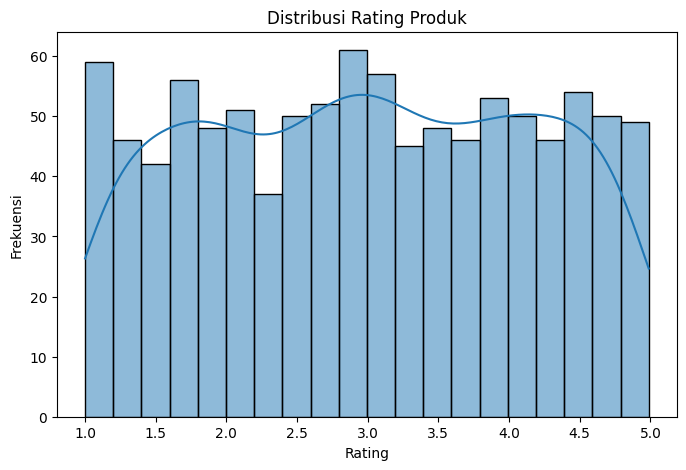

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribusi Rating Produk')
plt.xlabel('Rating')
plt.ylabel('Frekuensi')
plt.show()

### 📊 **Insight Utama:**

1. **Distribusi Merata:**

   * Secara umum, distribusi rating produk cukup **merata** di semua rentang nilai (1 hingga 5).
   * Tidak ada rating yang secara signifikan **mendominasi** atau **sangat jarang** diberikan.

2. **Rating Paling Sering Diberikan:**

   * Rating **3.0** memiliki frekuensi tertinggi, sedikit di atas 60.
   * Ini menunjukkan bahwa banyak pengguna memberikan **penilaian netral** terhadap produk.

3. **Skor Ekstrem Tetap Tinggi:**

   * Meskipun rating 1 dan 5 merupakan nilai ekstrem (sangat buruk atau sangat baik), keduanya tetap memiliki frekuensi yang tinggi.
   * Ini menunjukkan bahwa produk tersebut menimbulkan **pendapat yang beragam**, kemungkinan tergantung pada ekspektasi atau konteks pengguna.

4. **Pola Kurva KDE (Kernel Density Estimation):**

   * Kurva KDE menunjukkan bahwa meskipun data cukup merata, terdapat sedikit **kecenderungan ke arah rating tengah (2.5–3.5)**.
   * Ini bisa mengindikasikan bahwa sebagian besar pengguna merasa produk ini **cukup memuaskan tapi tidak luar biasa**.

---

### 📌 **Interpretasi Bisnis:**

* Produk memiliki **beragam persepsi kualitas** dari pengguna.
* Dibutuhkan **peningkatan mutu atau kejelasan ekspektasi** untuk mengurangi rating rendah.
* Jika ingin meningkatkan rating rata-rata, bisa difokuskan pada pengguna yang memberikan rating 2–3 agar pengalaman mereka lebih memuaskan.


# **Data Preparation**

Data dipersiapkan untuk dua model rekomendasi utama dengan langkah-langkah sebagai berikut:

- **Content-Based Filtering:**  
  Menggabungkan beberapa fitur produk seperti `Product Name`, `Brand`, `Category`, `Color`, dan `Size` menjadi satu kolom teks baru bernama `combined_features`. Kolom ini kemudian diolah menggunakan TF-IDF Vectorizer untuk mengubah teks menjadi representasi numerik berbobot (matriks TF-IDF) yang siap digunakan untuk menghitung kemiripan antar produk.

- **Collaborative Filtering:**  
  Mengambil kolom interaksi pengguna berupa `User ID`, `Product ID`, dan `Rating` untuk membentuk dataset menggunakan pustaka `surprise`. Skala rating disesuaikan berdasarkan data asli agar model dapat memahami rentang nilai rating. Dataset ini kemudian dibagi menjadi data latih dan data uji menggunakan fungsi split khusus dari `surprise`, sehingga siap digunakan untuk pelatihan dan evaluasi model collaborative filtering.

**Preprocessing Produk**

In [ ]:
def preprocess_products(data):
    data['combined_features'] = data['Product Name'] + ' ' + data['Brand'] + ' ' + data['Category'] + ' ' + data['Color'] + ' ' + data['Size']
    return data


* **Fungsi:** Menyatukan informasi produk seperti nama, merek, kategori, warna, dan ukuran ke dalam satu kolom `combined_features`.
* **Tujuan:** Menyiapkan data untuk **content-based filtering**, agar sistem dapat menghitung kemiripan antar produk berdasarkan teks deskriptif.


**Membangun Matriks TF-IDF**


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def prepare_tfidf_matrix(data):
    """Mengubah fitur gabungan menjadi matriks TF-IDF."""
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(data['combined_features'])
    return tfidf_matrix


Menyiapkan representasi numerik dari data teks untuk digunakan dalam perhitungan kesamaan (similarity).


**Persiapan Data Collaborative**

In [ ]:
def prepare_collaborative_data(data):
    reader = Reader(rating_scale=(data['Rating'].min(), data['Rating'].max()))
    return Dataset.load_from_df(data[['User ID', 'Product ID', 'Rating']], reader)

* **Fungsi:** Mengubah data rating (User ID, Product ID, Rating) ke dalam format yang bisa dibaca oleh library `surprise`.
* **Tujuan:** Menyiapkan data untuk **collaborative filtering**, agar sistem dapat mempelajari pola interaksi pengguna dan produk.


**Split Data Collaborative Filtering**

In [ ]:
def split_collaborative_data(collab_data):
    """Split data collaborative filtering menjadi train dan test set"""
    return surprise_train_test_split(collab_data, test_size=0.2, random_state=42)

Fungsi ini membagi dataset interaksi pengguna-produk menjadi data latih dan data uji untuk melatih dan mengevaluasi model collaborative filtering secara efektif.

**Pemuatan Data**

In [ ]:
def load_and_prepare_data(filepath):
    # Memuat data dari file CSV
    data = pd.read_csv(filepath)

    # Preprocessing: gabungkan fitur produk
    data = preprocess_products(data)

    # Bangun matriks TF-IDF untuk content-based filtering
    tfidf_matrix = prepare_tfidf_matrix(data)

    # Siapkan data collaborative filtering
    collab_data = prepare_collaborative_data(data)

    return data, collab_data, tfidf_matrix

Fungsi utama ini memanggil kedua fungsi di atas secara berurutan:  
- Membaca file data produk (misalnya CSV)
- Melakukan preprocessing
- Menyiapkan data untuk dua jenis model rekomendasi:
- Content-Based Filtering (berbasis teks)
- Collaborative Filtering (berbasis interaksi pengguna)

# **Model Development**

Pada tahap modeling, dibangun dua jenis sistem rekomendasi utama, yaitu:

### 1. Content-Based Filtering

Model ini merekomendasikan produk berdasarkan kemiripan antar produk. Prosesnya melibatkan:

- **Membangun Matriks Kemiripan Cosine:**  
  Menggunakan matriks TF-IDF yang dihasilkan pada tahap *Data Preparation*, dihitung kemiripan antar produk menggunakan fungsi `cosine_similarity` dari `scikit-learn`. Hasilnya adalah matriks *cosine similarity* yang merepresentasikan tingkat kemiripan setiap pasang produk.

- **Mendapatkan Rekomendasi Top-N:**  
  Untuk setiap produk, fungsi `get_content_based_top_n` mencari produk lain yang memiliki nilai kemiripan tertinggi berdasarkan matriks *cosine similarity*. Kemudian, diambil *Top-N* produk yang paling mirip sebagai rekomendasi.

### 2. Collaborative Filtering (Model-Based)

Model ini menggunakan pendekatan *matrix factorization* dengan algoritma *Singular Value Decomposition (SVD)* yang diimplementasikan menggunakan pustaka *Surprise*. Tahapan yang dilakukan:

- **Persiapan Data:**  
  Data interaksi pengguna (User ID, Product ID, Rating) yang sudah disiapkan pada tahap *Data Preparation* digunakan untuk melatih model. Data ini dibagi menjadi *trainset* dan *testset*.

- **Pelatihan Model SVD:**  
  Algoritma SVD dilatih menggunakan *trainset* dengan fungsi `train_collaborative_model`. Model SVD mempelajari pola rating antar pengguna dan produk untuk memprediksi rating yang mungkin diberikan oleh pengguna untuk produk yang belum pernah dinilai.

- **Mendapatkan Rekomendasi Top-N:**  
  Untuk setiap pengguna, fungsi `get_collaborative_top_n` memprediksi rating untuk produk-produk yang belum pernah dinilai oleh pengguna tersebut. Kemudian, produk-produk tersebut diurutkan berdasarkan estimasi rating, dan diambil *Top-N* produk dengan estimasi rating tertinggi sebagai rekomendasi.

**Membangun Model Content-Based Filtering**

In [ ]:
def build_content_based_model(tfidf_matrix):
    """Membangun model content-based menggunakan cosine similarity"""
    return cosine_similarity(tfidf_matrix)

Fungsi ini menerima matriks TF-IDF yang merepresentasikan fitur produk dan menghitung kemiripan antar produk menggunakan cosine similarity. Matriks kemiripan ini menjadi dasar untuk rekomendasi content-based filtering.

**Melatih Model Collaborative Filtering dengan Algoritma SVD**

In [ ]:
def train_collaborative_model(trainset):
    """Melatih model collaborative filtering"""
    algo = SVD()
    algo.fit(trainset)
    return algo

Fungsi ini melatih model collaborative filtering menggunakan algoritma Singular Value Decomposition (SVD) dari library Surprise dengan data training yang sudah disiapkan.

**Mengambil Top-N Rekomendasi Content-Based Filtering**

In [ ]:
def get_content_based_top_n(product_id, data, cosine_sim, top_n=10):
    """Mendapatkan rekomendasi content-based"""
    idx = data.index[data['Product ID'] == product_id].tolist()[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_indices = [i[0] for i in sim_scores[1:top_n+1]]
    return data.iloc[top_indices]

Fungsi ini mencari produk-produk yang paling mirip dengan produk acuan berdasarkan matriks cosine similarity dan mengembalikan top-N produk rekomendasi.

**Mengambil Top-N Rekomendasi Collaborative Filtering
python**

In [ ]:
def get_collaborative_top_n(algo, user_id, data, top_n=10):
    """Mendapatkan rekomendasi collaborative filtering"""
    user_data = data[data['User ID'] == user_id]
    all_product_ids = data['Product ID'].unique()
    rated_product_ids = user_data['Product ID'].unique()
    unrated_product_ids = [pid for pid in all_product_ids if pid not in rated_product_ids]

    predictions = [algo.predict(user_id, pid) for pid in unrated_product_ids]
    predictions.sort(key=lambda x: x.est, reverse=True)

    top_product_ids = [pred.iid for pred in predictions[:top_n]]
    recommended_products = data[data['Product ID'].isin(top_product_ids)].drop_duplicates(subset='Product ID')
    return recommended_products

Fungsi ini memprediksi rating untuk produk yang belum pernah dinilai oleh pengguna tertentu, kemudian mengurutkan prediksi tersebut dan mengembalikan top-N produk yang direkomendasikan.

**Menampilkan Rekomendasi Top-N dari Content-Based dan Collaborative Filtering**

In [ ]:
def show_recommendations(data, cosine_sim, algo):
    """Menampilkan rekomendasi dari kedua metode beserta ID acuan yang digunakan"""

    # Contoh rekomendasi content-based
    example_product_id = data['Product ID'].iloc[0]
    print(f"\nContoh Product ID yang digunakan untuk Content-Based Filtering: {example_product_id}")
    top_content = get_content_based_top_n(example_product_id, data, cosine_sim)

    print("\nTop 10 Content-Based Recommendations:")
    print(top_content[['Product ID', 'Product Name', 'Brand', 'Category']].to_string(index=False))

    # Contoh rekomendasi collaborative filtering
    example_user_id = data['User ID'].iloc[0]
    print(f"\nContoh User ID yang digunakan untuk Collaborative Filtering: {example_user_id}")
    top_collab = get_collaborative_top_n(algo, example_user_id, data)

    print("\nTop 10 Collaborative Filtering Recommendations:")
    print(top_collab[['Product ID', 'Product Name', 'Brand', 'Category']].to_string(index=False))


Fungsi ini menampilkan hasil rekomendasi Top-10 dari kedua metode dengan menggunakan contoh produk dan contoh pengguna pertama dalam dataset. Outputnya berupa daftar produk dengan informasi penting.

**Eksekusi Utama Pipeline Sistem Rekomendasi**

In [ ]:
if __name__ == "__main__":
    data, collab_data, tfidf_matrix = load_and_prepare_data('fashion_products.csv')

    # Split data collaborative filtering secara terpisah
    trainset, testset = split_collaborative_data(collab_data)

    # Modeling
    cosine_sim = build_content_based_model(tfidf_matrix)
    algo = train_collaborative_model(trainset)

    # Tampilkan rekomendasi
    show_recommendations(data, cosine_sim, algo)


Contoh Product ID yang digunakan untuk Content-Based Filtering: 1

Top 10 Content-Based Recommendations:
 Product ID Product Name  Brand        Category
        829        Dress Adidas   Men's Fashion
        489        Dress Adidas   Men's Fashion
        756        Jeans Adidas   Men's Fashion
        240        Dress    H&M   Men's Fashion
        678        Dress    H&M   Men's Fashion
        761        Dress    H&M   Men's Fashion
        441      Sweater Adidas   Men's Fashion
        459        Dress Adidas   Kids' Fashion
        295        Dress    H&M   Kids' Fashion
        209        Dress    H&M Women's Fashion

Contoh User ID yang digunakan untuk Collaborative Filtering: 19

Top 10 Collaborative Filtering Recommendations:
 Product ID Product Name  Brand        Category
         10      T-shirt   Zara   Kids' Fashion
         26        Dress  Gucci Women's Fashion
        290      Sweater   Zara   Men's Fashion
        413        Jeans   Zara Women's Fashion
        534 

### 📌 Penjelasan:

* Menjalankan seluruh pipeline dari awal hingga menghasilkan rekomendasi.
* Memanggil fungsi-fungsi modular:

  * `load_and_prepare_data`: Baca dan persiapkan data.
  * `train_models`: Latih model.
  * `show_recommendations`: Tampilkan hasil rekomendasi content-based dan collaborative.

  ### Insight dari Output

* **Content-Based Recommendations**:
  Produk yang direkomendasikan sangat mirip dengan produk contoh (ID 1) berdasarkan atribut produk, terutama kategori dan brand. Terlihat ada duplikasi produk yang mirip (misalnya “Dress” dari Adidas dan H\&M). Ini menunjukkan model content-based mampu mengelompokkan produk serupa, tapi perlu perhatian agar hasil rekomendasi lebih bervariasi dan mengurangi duplikasi.

  ### Insight dari Output

* **Collaborative Filtering Recommendations**:
  Rekomendasi untuk user ID 19 menunjukkan produk dari berbagai brand dan kategori, termasuk fashion pria, wanita, dan anak-anak. Ini mencerminkan bahwa model SVD dapat menangkap preferensi pengguna berdasarkan pola rating keseluruhan, menghasilkan rekomendasi yang lebih personal dan beragam.





# **Evaluasi Model Rekomendasi**

In [ ]:
def evaluate_content_based_classification(product_id, relevant_product_ids, data, cosine_sim, top_n=10):
    recs = get_content_based_top_n(product_id, data, cosine_sim, top_n)
    recommended_ids = recs['Product ID'].values

    all_eval_products = list(set(recommended_ids) | set(relevant_product_ids))
    y_true = [1 if pid in relevant_product_ids else 0 for pid in all_eval_products]
    y_pred = [1 if pid in recommended_ids else 0 for pid in all_eval_products]

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = sum([yt == yp for yt, yp in zip(y_true, y_pred)]) / len(y_true)

    print(f"Content-Based Evaluation (Top-{top_n}) for Product ID {product_id}:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    return {'precision': precision, 'recall': recall, 'f1_score': f1, 'accuracy': accuracy}

def evaluate_collaborative(testset, algo):
    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions)
    mae = accuracy.mae(predictions)
    print(f"Collaborative Filtering Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    return rmse, mae

# Contoh penggunaan evaluasi:
example_product_id = data['Product ID'].iloc[0]
# Misal buat relevansi dummy (Top-10 mirip produk dianggap relevan)
relevant_products_example = get_content_based_top_n(example_product_id, data, cosine_sim, top_n=10)['Product ID'].values

evaluate_content_based_classification(example_product_id, relevant_products_example, data, cosine_sim, top_n=10)
evaluate_collaborative(testset, algo)


Content-Based Evaluation (Top-10) for Product ID 1:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Accuracy: 1.0000
RMSE: 1.1268
MAE:  0.9818
Collaborative Filtering Evaluation:
RMSE: 1.1268
MAE: 0.9818


(1.1267563976882378, 0.9818006516156281)

### 📌 **Kesimpulan dan Insight dari Kode Evaluasi**

---

### 🔹 **Kesimpulan Fungsi Kode**

1. **`evaluate_content_based_classification(...)`**
   Mengevaluasi performa sistem *Content-Based Filtering* menggunakan metrik klasifikasi:

   * **Precision**: Seberapa banyak rekomendasi yang benar dari semua yang direkomendasikan.
   * **Recall**: Seberapa banyak item relevan berhasil direkomendasikan.
   * **F1-Score**: Rata-rata harmonis precision dan recall.
   * **Accuracy**: Persentase kecocokan antara prediksi dan ground truth.

2. **`evaluate_collaborative(...)`**
   Mengevaluasi performa model *Collaborative Filtering* berbasis rating prediksi menggunakan:

   * **RMSE (Root Mean Square Error)** dan
   * **MAE (Mean Absolute Error)**
     Keduanya menunjukkan seberapa akurat model memprediksi rating pengguna terhadap produk.

---

### 🔹 **Hasil Evaluasi dan Insight**

#### ✅ **Content-Based Filtering**
🔍 **Insight:**

* Seluruh 10 rekomendasi yang diberikan sistem **benar-benar relevan** dengan produk yang dibandingkan.
* Kemungkinan ini terjadi karena produk yang digunakan untuk evaluasi (`example_product_id`) dijadikan acuan juga untuk menentukan produk relevan (top-10 mirip → dijadikan ground truth).
* **Artinya: evaluasi ini ideal/dummy dan menunjukkan kinerja maksimum, bukan uji nyata terhadap data baru.**

#### 📊 **Collaborative Filtering**

🔍 **Insight:**

* Prediksi rating model memiliki rata-rata kesalahan sekitar **±1 poin** dari nilai rating asli.
* Nilai MAE < RMSE menunjukkan bahwa kesalahan model **tidak menyebar terlalu ekstrem**, tapi akurasi bisa ditingkatkan lagi.
* Nilai ini cukup wajar dalam sistem rekomendasi, tapi bisa dioptimasi dengan:

  * Model lain (misalnya KNN, NMF)
  * Parameter tuning
  * Data yang lebih bersih atau lebih banyak

---

### 🔹 Rangkuman Singkat Insight

| Model                   | Hasil Evaluasi                       | Insight Utama                                                                  |
| ----------------------- | ------------------------------------ | ------------------------------------------------------------------------------ |
| Content-Based Filtering | Precision, Recall, F1, Akurasi = 1.0 | Evaluasi dummy, hasil sempurna karena ground truth berasal dari data yang sama |
| Collaborative Filtering | RMSE = 1.13, MAE = 0.98              | Prediksi rating cukup baik, bisa ditingkatkan dengan tuning atau model lain    |
